Dataset loaded: 891 rows × 12 columns

Best Parameters:
{'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 150}

Test Accuracy      : 80.45%
Test ROC-AUC Score : 0.8411
CV ROC-AUC Mean    : 0.8798 ± 0.0303

Classification Report:

              precision    recall  f1-score   support

    Perished       0.80      0.90      0.85       110
    Survived       0.80      0.65      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.78       179
weighted avg       0.80      0.80      0.80       179


Model saved as titanic_survival_model.pkl


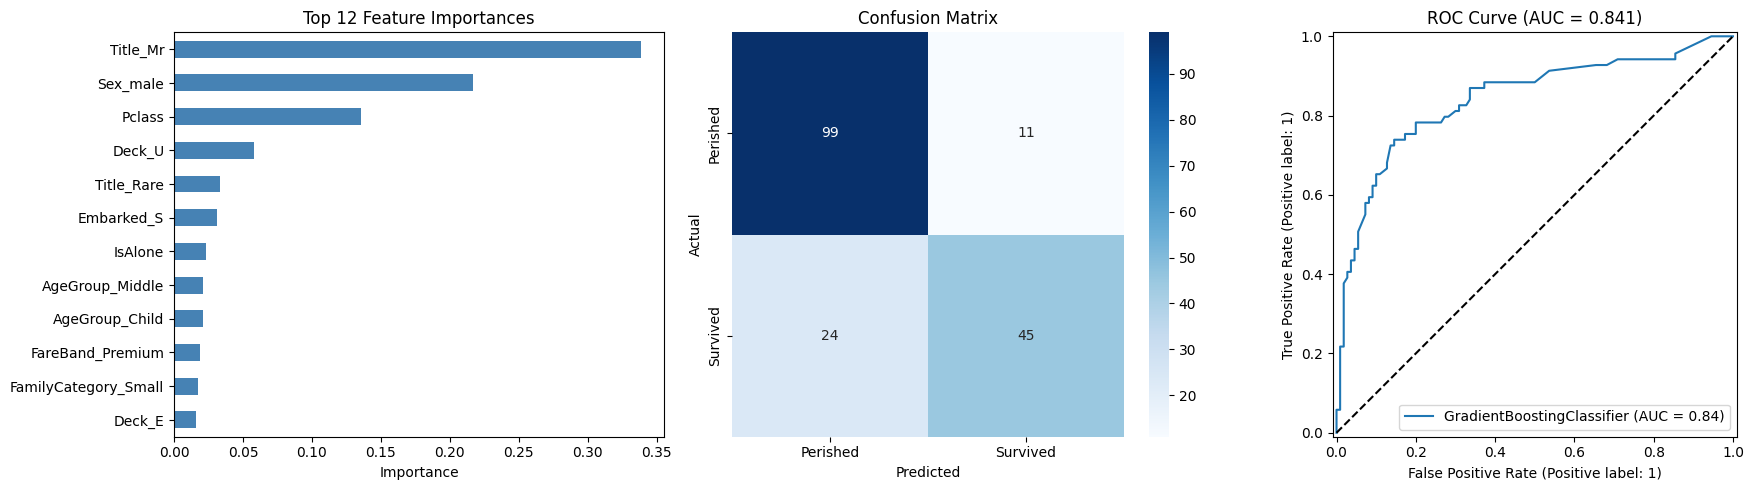

In [1]:

# CODSOFT : DATA SCIENCE
# TASK 1: TITANIC SURVIVAL PREDICTION — ENHANCED PIPELINE
# AUTHOR: SALIK KHAN

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay
)
import joblib
import warnings

warnings.filterwarnings('ignore')


# 1. DATA ACQUISITION
# -------------------------------------------------------------------------

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")


# 2. FEATURE ENGINEERING

#  Title extraction & grouping
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

title_mapping = {
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs',
    'Lady': 'Rare',
    'Countess': 'Rare',
    'Capt': 'Rare',
    'Col': 'Rare',
    'Don': 'Rare',
    'Dr': 'Rare',
    'Major': 'Rare',
    'Rev': 'Rare',
    'Sir': 'Rare',
    'Jonkheer': 'Rare',
    'Dona': 'Rare'
}

df['Title'] = df['Title'].replace(title_mapping)

#  Family features
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Categorize family siz
def family_category(size):
    if size == 1:
        return 'Solo'
    elif size <= 4:
        return 'Small'
    else:
        return 'Large'

df['FamilyCategory'] = df['FamilySize'].apply(family_category)

#  Deck extraction from Cabin
df['Deck'] = df['Cabin'].str[0].fillna('U')

#  Fare binning (quartiles)
df['FareBand'] = pd.qcut(
    df['Fare'].fillna(df['Fare'].median()),
    q=4,
    labels=['Low', 'Mid', 'High', 'Premium']
)

# 3. IMPUTATION


# Age: impute by Title-based median
df['Age'] = df.groupby('Title')['Age'].transform(
    lambda x: x.fillna(x.median())
)

# Age grouping
def age_group(age):
    if age <= 12:
        return 'Child'
    elif age <= 18:
        return 'Teen'
    elif age <= 35:
        return 'Adult'
    elif age <= 60:
        return 'Middle'
    else:
        return 'Senior'

df['AgeGroup'] = df['Age'].apply(age_group)

# Embarked: fill with mode
df['Embarked'] = df['Embarked'].fillna(
    df['Embarked'].mode()[0]
)

# 4. DROP UNUSED COLUMNS & ENCODE (With Robust Error Fix)

drop_cols = [
    'PassengerId',
    'Name',
    'Ticket',
    'Cabin',
    'Age',
    'Fare',
    'SibSp',
    'Parch',
    'FamilySize'
]

# FIX: Safely filters and only drops columns if they exist in the current dataframe state
existing_drop_cols = [col for col in drop_cols if col in df.columns]
df.drop(columns=existing_drop_cols, inplace=True)

# One-hot encoding
df = pd.get_dummies(
    df,
    columns=[
        'Sex',
        'Embarked',
        'Title',
        'Deck',
        'FareBand',
        'FamilyCategory',
        'AgeGroup'
    ],
    drop_first=True
)

# 5. TRAIN-TEST SPLIT

X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 6. HYPERPARAMETER TUNING USING GRID SEARCH

param_grid = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

gb = GradientBoostingClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("\nBest Parameters:")
print(grid_search.best_params_)

# 7. MODEL EVALUATION

y_pred = best_model.predict(X_test)

y_proba = best_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_proba)

cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc'
)

print("\n" + "=" * 50)
print(f"Test Accuracy      : {accuracy:.2%}")
print(f"Test ROC-AUC Score : {roc_auc:.4f}")
print(
    f"CV ROC-AUC Mean    : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}"
)
print("=" * 50)

print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Perished', 'Survived']
    )
)


# 8. SAVE MODEL


joblib.dump(best_model, "titanic_survival_model.pkl")

print("\nModel saved as titanic_survival_model.pkl")


# 9. VISUALIZATIONS


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Feature Importance
importances = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values().tail(12)

importances.plot(
    kind='barh',
    ax=axes[0],
    color='steelblue'
)

axes[0].set_title('Top 12 Feature Importances')
axes[0].set_xlabel('Importance')

# Confusion Matrix
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[1],
    xticklabels=['Perished', 'Survived'],
    yticklabels=['Perished', 'Survived']
)

axes[1].set_title('Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

# ROC Curve
RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    ax=axes[2]
)

axes[2].plot([0, 1], [0, 1], 'k--')
axes[2].set_title(f'ROC Curve (AUC = {roc_auc:.3f})')

plt.tight_layout()
plt.show()